# kNN implementation


---

### 01. Downloading libs


In [1]:
%pip install imbalanced-learn matplotlib numpy pandas scikit-learn seaborn



[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 02. Importing libs


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from imblearn.over_sampling import RandomOverSampler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler


### 03. Importing and pre-processing the initial data of the dataframe


Looking at the dataset that will be processed, this is the **MAGIC Gamma Telescope Dataset** which contains data from a ground-based atmospheric Cherenkov gamma telescope. The dataset is used for classification of high energy gamma particles from hadrons (background noise).

**Dataset characteristics:**
- **Total samples**: 19,020 observations
- **Features**: 10 continuous variables measuring telescope imaging parameters
- **Target**: Binary classification (Gamma particles vs Hadrons)
    - Class 1: Gamma particles (signal)
    - Class 0: Hadrons (background)

**Feature descriptions:**
- `fLength`: Major axis of ellipse [mm]
- `fWidth`: Minor axis of ellipse [mm]  
- `fSize`: 10-log of sum of content of all pixels [in #phot]
- `fConc`: Ratio of sum of two highest pixels over fSize [ratio]
- `fConc1`: Ratio of highest pixel over fSize [ratio]
- `fAsym`: Distance from highest pixel to center, projected onto major axis [mm]
- `fM3Long`: 3rd root of third moment along major axis [mm]
- `fM3Trans`: 3rd root of third moment along minor axis [mm]
- `fAlpha`: Angle of major axis with vector to origin [deg]
- `fDist`: Distance from origin to center of ellipse [mm]

The goal is to distinguish between gamma-ray showers (which are of astrophysical interest) and hadronic showers initiated by cosmic rays in the upper atmosphere (which represent background noise).


In [3]:
# Importing and checking the dataframe

dataframe = pd.read_csv('../../datasets/magic_gamma_telescope/magic04.data', header = None)
dataframe.head()


,0,1,2,3,4,5,6,7,8,9,10
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [4]:
# Renaming columns accordingly to the dataset documentation

columns_name = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
dataframe.columns = columns_name
dataframe.head()


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [5]:
# Mapping the classes to numerical values

dataframe['class'] = dataframe['class'].map({'g': 1, 'h': 0})
dataframe.head()


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


### 04. Checking the histogram of the dataset


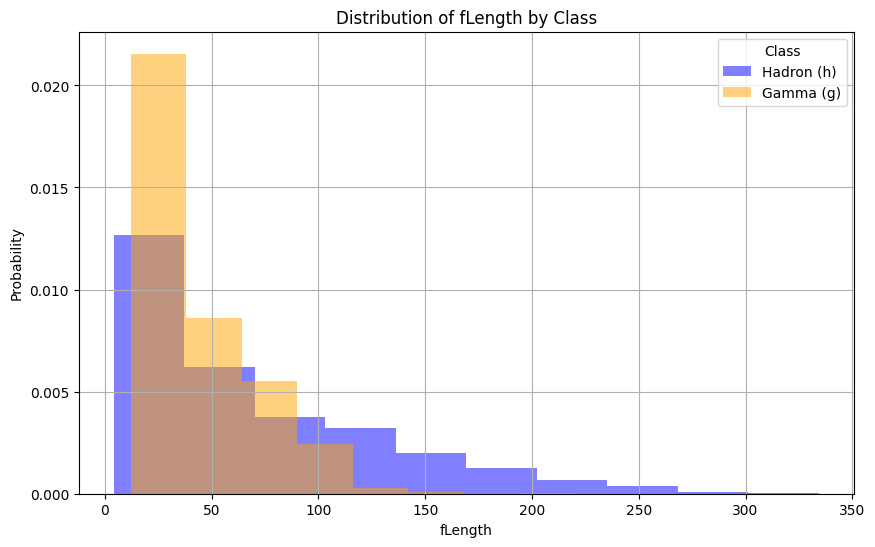

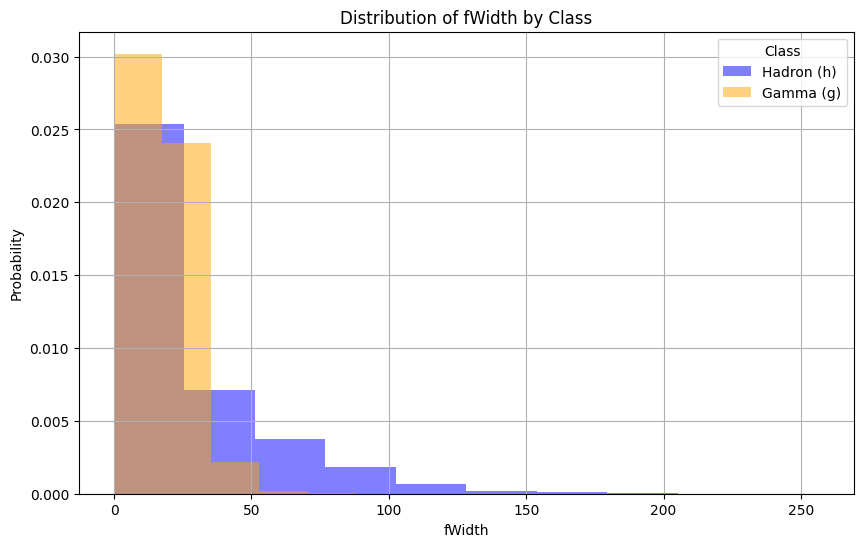

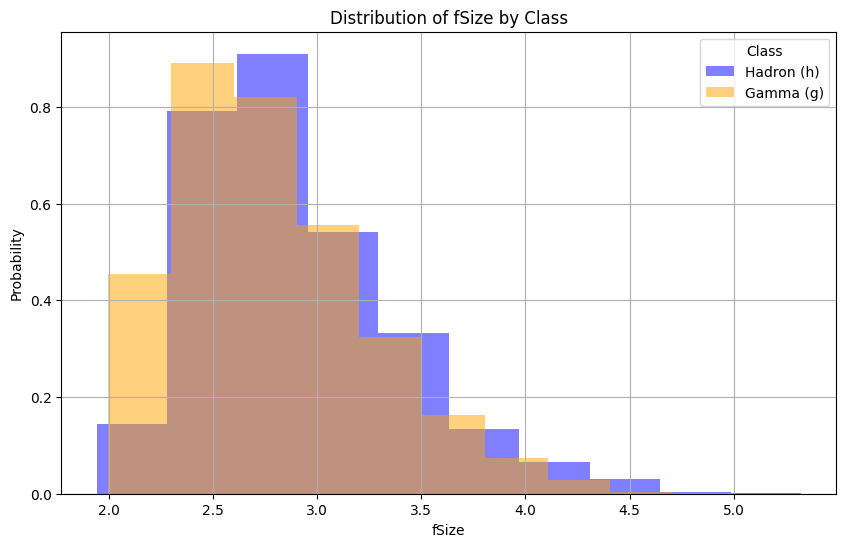

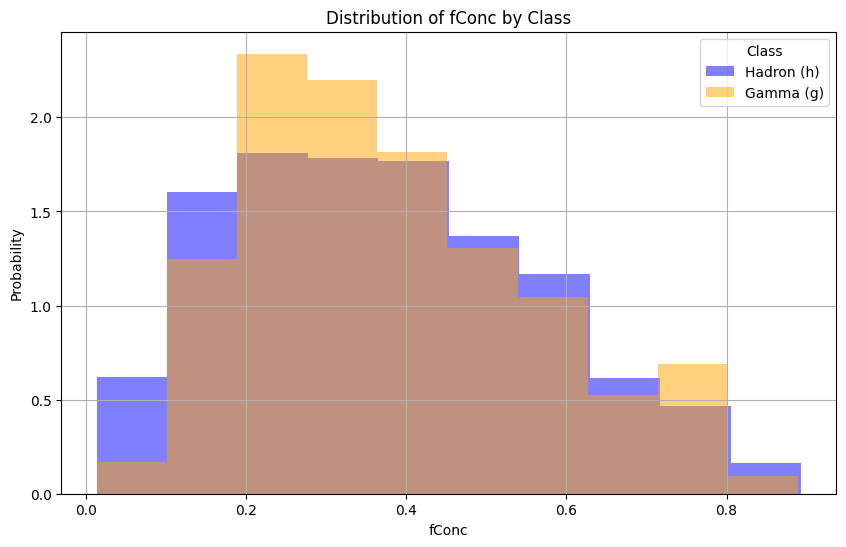

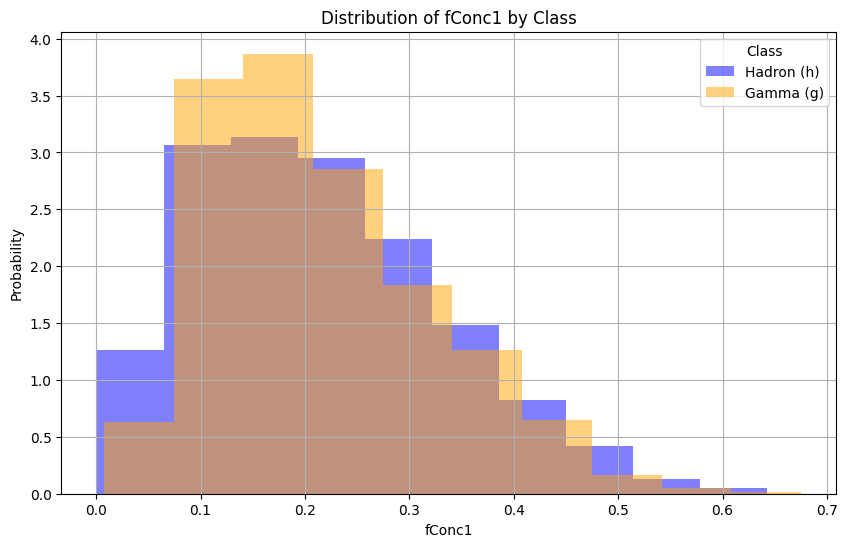

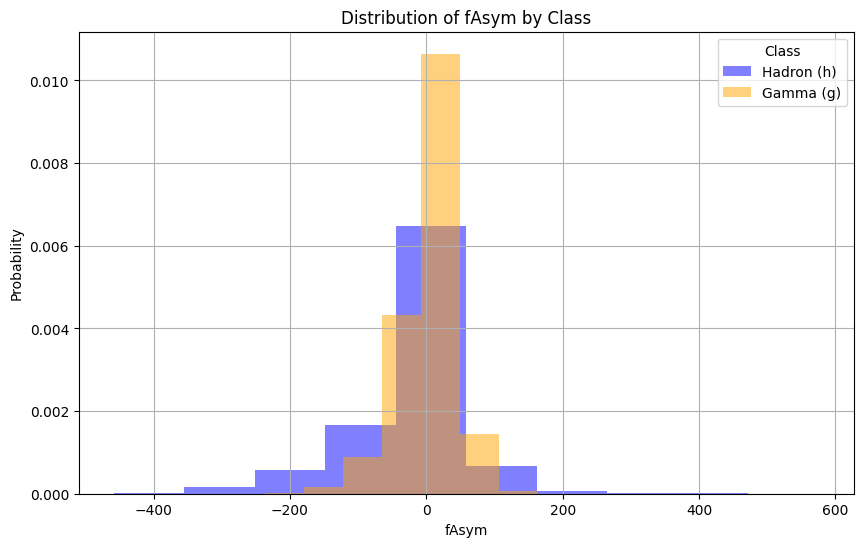

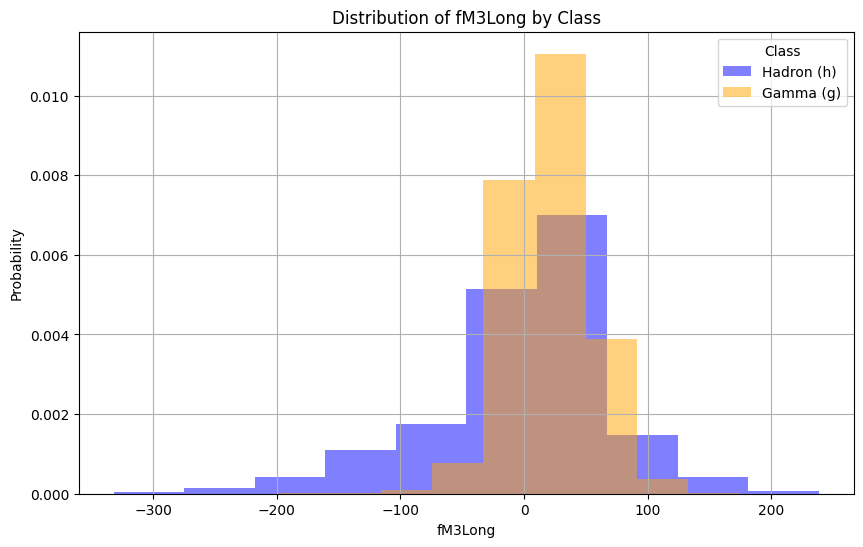

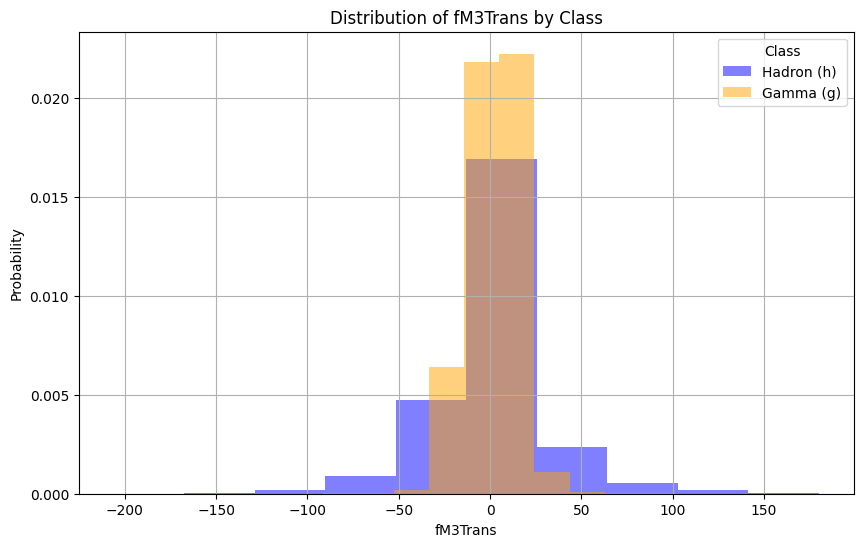

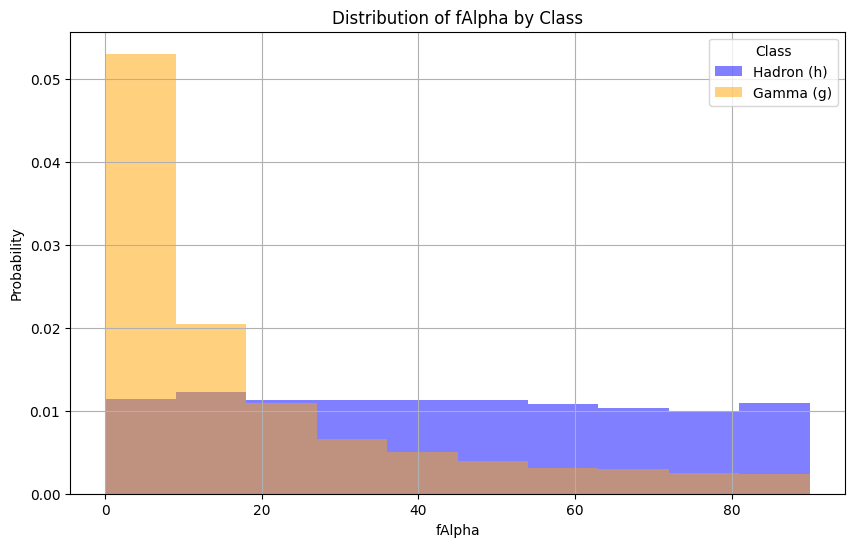

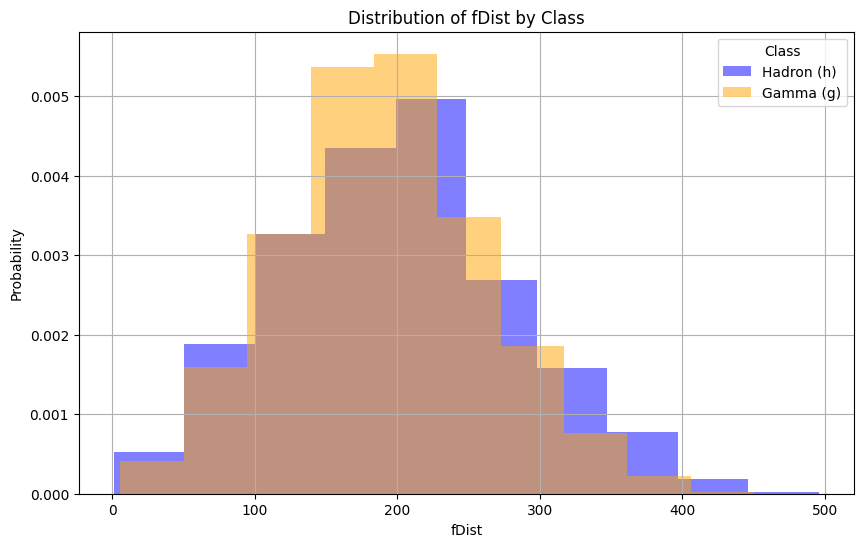

In [6]:
for label in columns_name[:-1]:
    plt.figure(figsize = (10, 6))

    plt.hist(dataframe[dataframe['class'] == 0][label], label = 'Hadron (h)', density = True, alpha = 0.5, color = 'blue')
    plt.hist(dataframe[dataframe['class'] == 1][label], label = 'Gamma (g)', density = True, alpha = 0.5, color = 'orange')

    plt.title(f'Distribution of {label} by Class')
    plt.xlabel(label)
    plt.ylabel('Probability')
    plt.legend(title = 'Class')
    plt.grid()

    plt.show()


### 05. Defining the train, validation and test datasets


In [7]:
# Shuffling the dataframe

dataframe = dataframe.sample(frac = 1, random_state = 42).reset_index(drop = True)


In [8]:
dataframe.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.6 MB


In [9]:
dataframe.head()


,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,48.0573,11.0862,2.9571,0.3620,0.1882,0.4200,32.4358,-2.2992,26.9300,165.2240,0
1,23.4858,0.0000,2.2393,0.7378,0.3775,-2.9397,13.0915,0.0001,19.3410,235.3420,1
2,40.5429,19.4073,3.3382,0.2369,0.1269,29.1908,27.0567,-7.1243,10.0643,195.6030,1
3,16.6123,7.8423,2.5572,0.5829,0.3371,6.7271,-10.3448,-2.3240,14.5111,214.2655,0
4,205.4250,37.7936,3.2727,0.2167,0.1257,46.0952,-210.9350,-29.7478,60.0580,206.1730,0


In [10]:
# Defining a function to scale the data and oversample if necessary

def scale_data(dataframe, oversample = False):
    features = dataframe.columns[:-1]
    target = dataframe.columns[-1]

    X = dataframe[features].values
    y = dataframe[target].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler(random_state = 42)
        X_resampled, y_resampled = ros.fit_resample(X_scaled, y)
        dataframe_scaled = np.hstack((X_resampled, np.reshape(y_resampled, (-1, 1))))
        return dataframe_scaled, X_resampled, y_resampled
    else:
        dataframe_scaled = np.hstack((X_scaled, np.reshape(y, (-1, 1))))
        return dataframe_scaled, X_scaled, y


In [11]:
# Defining the train, validation and test datasets sizes

train_size = 0.7
validation_size = 0.15
test_size = 0.15


In [12]:
# Defining the train, validation and test datasets

train_dataset = dataframe[:int(train_size * len(dataframe))]
validation_dataset = dataframe[int(train_size * len(dataframe)):int((train_size + validation_size) * len(dataframe))]
test_dataset = dataframe[int((train_size + validation_size) * len(dataframe)):]

print('\nDatasets sizes before scaling and oversampling:')
print(f'Train dataset size: {len(train_dataset)} samples')
print(f'Validation dataset size: {len(validation_dataset)} samples')
print(f'Test dataset size: {len(test_dataset)} samples')



Datasets sizes before scaling and oversampling:
Train dataset size: 13314 samples
Validation dataset size: 2853 samples
Test dataset size: 2853 samples


In [13]:
# Scaling and oversampling the datasets

train_dataset, X_train, y_train = scale_data(train_dataset, oversample = True)
validation_dataset, X_validation, y_validation = scale_data(validation_dataset, oversample = False)
test_dataset, X_test, y_test = scale_data(test_dataset, oversample = False)

print('\nDatasets sizes after scaling and oversampling:')
print(f'Train dataset size: {len(train_dataset)} samples')
print(f'Validation dataset size: {len(validation_dataset)} samples')
print(f'Test dataset size: {len(test_dataset)} samples')



Datasets sizes after scaling and oversampling:
Train dataset size: 17300 samples
Validation dataset size: 2853 samples
Test dataset size: 2853 samples


### 06. kNN implementation


In [14]:
# kNN implementation

for number_neighbors in range(1, 5, 2):
    knn_model = KNeighborsClassifier(n_neighbors = number_neighbors)
    knn_model.fit(X_train, y_train)

    y_predictions_validation = knn_model.predict(X_validation)
    y_predictions_test = knn_model.predict(X_test)

    print(f'\nNumber of Neighbors: {number_neighbors}')
    print('Validation Set Classification Report:')
    print(classification_report(y_validation, y_predictions_validation))

    print('Test Set Classification Report:')
    print(classification_report(y_test, y_predictions_test))



Number of Neighbors: 1
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.70      0.73      1033
           1       0.84      0.88      0.86      1820

    accuracy                           0.81      2853
   macro avg       0.80      0.79      0.80      2853
weighted avg       0.81      0.81      0.81      2853

Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.68      0.72       991
           1       0.84      0.89      0.86      1862

    accuracy                           0.82      2853
   macro avg       0.80      0.78      0.79      2853
weighted avg       0.81      0.82      0.81      2853


Number of Neighbors: 3
Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73      1033
           1       0.84      0.86      0.85      1820

    accuracy              